In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import itertools
import math

from config import *
from util import *

In [2]:
df_pollen = pd.read_csv("data/boreal_forest/"+CHARCOAL_ID+"_spec.csv")
df_pollen = df_pollen.rename(columns={"Profondeur": "Depth"})
df_pollen.columns = df_pollen.columns.str.strip()
display(df_pollen)

,Depth,Abies,Juniperus,Larix,Picea,Pinus,Tsuga,Acer,Alnus,Betula,...,Myrica,Phytolithe,Poaceae,Rosaceae,Sarcobatus,Thalictrum,Typha,Spore monolete,Spore trilete,Aquatics
0,570,1.095890,0.273973,1.917808,16.712329,53.698630,0.000000,0.000000,1.917808,8.219178,...,0.547945,0.273973,1.369863,0.000000,0.000000,0.000000,0.273973,0.00000,0.000000,0.000000
1,580,0.906344,0.302115,0.604230,13.897281,62.235650,0.302115,0.000000,0.604230,10.574018,...,0.000000,0.000000,1.208459,0.000000,0.000000,0.000000,0.000000,0.60423,0.302115,0.000000
2,590,0.840336,0.840336,1.680672,14.005602,59.383753,0.000000,0.000000,0.560224,9.523810,...,0.280112,0.000000,1.400560,0.000000,0.000000,0.000000,0.280112,0.00000,0.000000,0.000000
3,600,1.056338,0.264085,2.640845,12.147887,52.816901,0.000000,0.000000,5.545775,13.204225,...,0.528169,0.000000,1.584507,0.264085,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,610,1.744186,0.000000,1.744186,16.694352,55.315615,0.000000,0.249169,0.996678,9.219269,...,0.498339,0.000000,4.235880,0.000000,0.000000,0.249169,0.000000,0.00000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,1140,0.000000,0.307062,2.456499,25.793245,31.320368,0.000000,0.000000,0.307062,21.494371,...,0.307062,0.000000,3.991812,0.000000,0.000000,0.000000,1.535312,0.00000,0.000000,0.000000
58,1150,0.000000,0.568182,1.136364,13.068182,51.704545,0.000000,0.000000,0.000000,15.909091,...,0.568182,0.000000,5.681818,0.000000,0.284091,0.000000,0.284091,0.00000,0.000000,0.284091
59,1160,0.000000,1.863354,0.621118,10.559006,57.142857,0.000000,0.000000,0.310559,12.422360,...,0.310559,0.000000,3.416149,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
60,1170,0.000000,0.595238,1.785714,17.559524,54.166667,0.000000,0.000000,0.000000,10.119048,...,0.000000,0.000000,3.273810,0.000000,0.000000,0.000000,0.297619,0.00000,0.000000,0.297619


## Modèle

$$
\frac{dX_s}{dt}
= r_s\,X_s\left(1 - \frac{X_s}{K_s}\right)
+ X_s \sum_{j} a_{j \to s}\,X_j
$$



### Paramètres

#### Selection des espèces utilisées

Ces espèces réelles influenceront chacune des espèces générées

In [3]:
SELECTED_POLLEN = ['Picea', 'Pinus', 'Alnus', 'Betula', 'Quercus', 'Ambrosia', 'Chenopodiaceae']
df_pollen = df_pollen[[c for c in df_pollen.columns if c in SELECTED_POLLEN or c == 'Depth'  ]]
n_pollen = len(SELECTED_POLLEN)

In [4]:
moyenne_pollen = df_pollen.mean().values[1:]

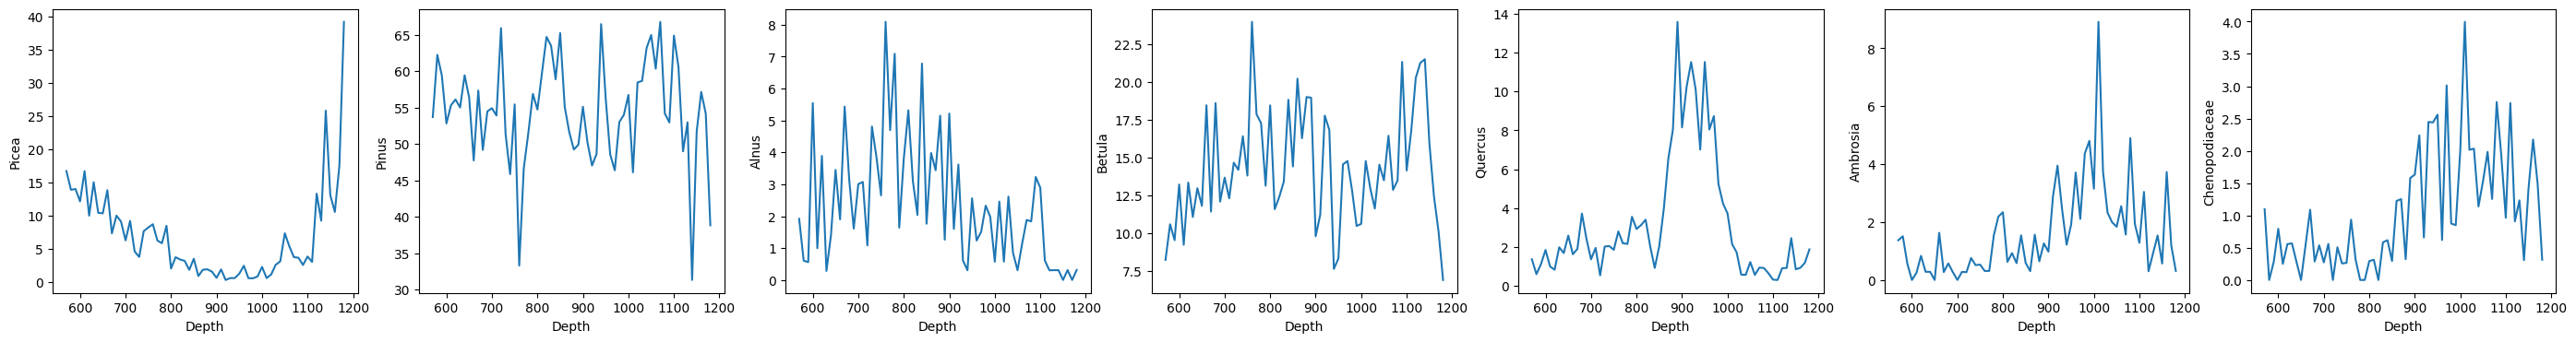

In [5]:
n_rows = 1
n_cols = len(df_pollen.columns) -1

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=True,
    sharey=False
)

if DEBUG:
    i_l = 0
    for col in df_pollen.columns:

        if col != "Depth":

            sns.lineplot(
                data=df_pollen,
                x="Depth",
                y=col,
                ax=axes[i_l]
            )
            
            i_l +=1

#### Nombre d'espèces générés et nombre d'espèces utilisées

In [6]:
N_A = 100
N_r = 7
N_K = 7
n_ones_min = 1
n_ones_max = n_pollen 
## n_ones_max = 1 pour n'avoir qu'une espèce qui impacte l'espèce générée

In [7]:
nb_ones = np.random.randint(1, n_ones_max+1, N_A)

Ones = np.zeros(( N_A, n_pollen), dtype=int)

for i in range(N_A):
    idx = np.random.choice(n_pollen, nb_ones[i], replace=False)
    Ones[ i, idx] = 1

## Ones : matrice bouléenne indiquant les espèces utilisées pour chaque espèce générée


#### Matrice des interactions et paramètres du modèles

In [ ]:
ordre_interactions = 0.2      
A = ordre_interactions*(np.random.random((N_A,n_pollen))-0.2) ## intéractions positives ou négatives
A = A*Ones/moyenne_pollen ## selection et normalisation
#A = df_A.loc[range(N),SELECTED_POLLEN]

r = np.random.uniform(0.06, 0.1, N_A)
k = np.random.uniform(0.8, 1.2, N_A)



## Générations des espèces

In [25]:
df_pollen_synth = generation_synthetique(df_pollen, r ,  k , A, "Depth",
                                            reverse_tmp=True, init=1, col_selection=None) 

[100] : 100 espèces générées sur 61 intérations.


c:\Users\mehls\Documents\ECN\Projet Forêt Boréal\github\boreal-forest\util.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sorted[col_name] = Synth[*i_d,:]
c:\Users\mehls\Documents\ECN\Projet Forêt Boréal\github\boreal-forest\util.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sorted[col_name] = Synth[*i_d,:]


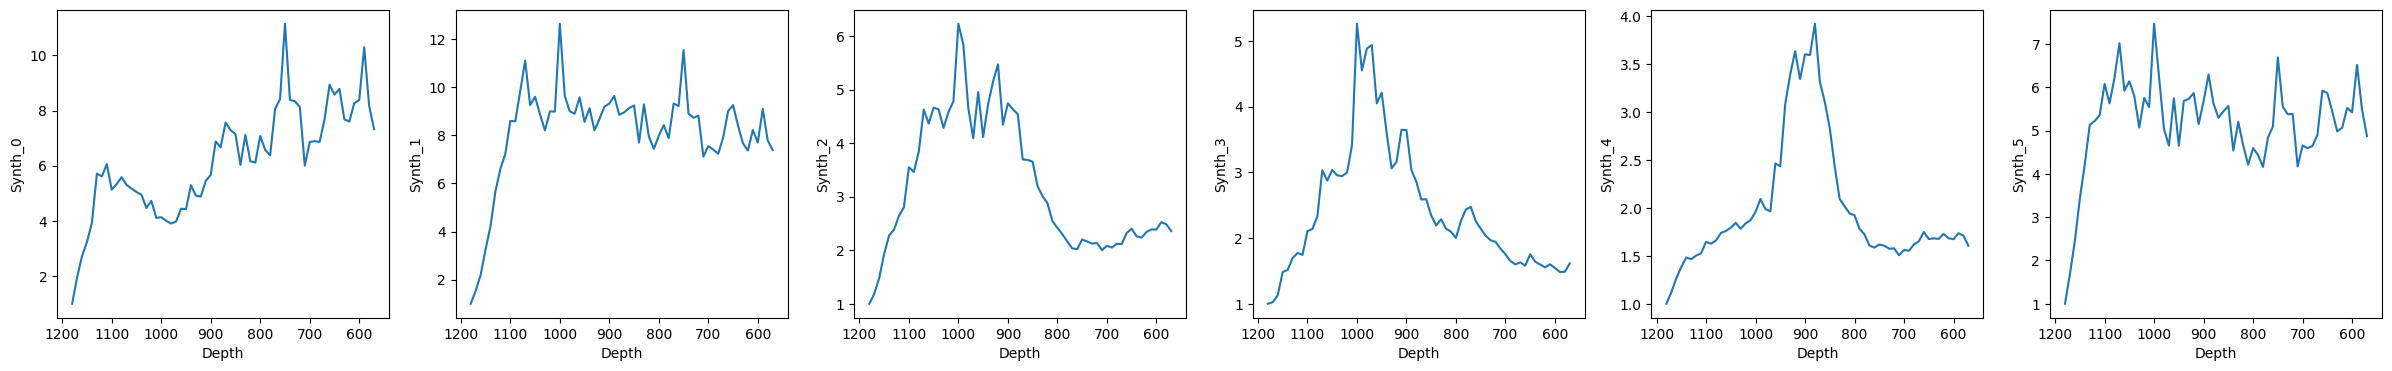

In [26]:
ip = 0


n_rows = 1
n_cols = 6

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)

ip = 0
for col in df_pollen_synth.columns:

    if col[:6] == "Synth_" and ip < n_cols:

        ax = axes[ip]
        sns.lineplot(
            data=df_pollen_synth,
            x="Depth",
            y=col,
            ax=ax
        )
        
        ax.invert_xaxis()

        '''
        i = int(col.split("_")[1])
        ones = np.where((A[i]!=0))[0]
        ax.text(
            0.5, -0.15,                      
            f"Indices des pollens utilisés : {ones}, {A[i][ones]}",
            ha='center', va='center',
            transform=ax.transAxes
        )       '''


        ip +=1



## Enregistrement des données

In [29]:

df_A = pd.DataFrame(A, columns=SELECTED_POLLEN)
df_rk = pd.DataFrame(np.concatenate([r[:, None], k[:, None]], axis = 1), columns=["r", "k"])

In [30]:
import os

SAVE_DIR = "data_generated"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Dossier créé :", SAVE_DIR)
# Sauvegarde des DataFrames
df_pollen_synth.to_csv(os.path.join(SAVE_DIR, "df_pollen_synth.csv"), index=False)
df_A.to_csv(os.path.join(SAVE_DIR, "df_A.csv"), index=False)
df_rk.to_csv(os.path.join(SAVE_DIR, "df_rk.csv"), index=False)

print("DataFrames sauvegardés.")

Dossier créé : data_generated
DataFrames sauvegardés.
